In [4]:
import pandas as pd

df = pd.read_csv("data[1].csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
df.shape

(4600, 18)

In [6]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [7]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [8]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='area', y='price', data=df)
plt.show()

ValueError: Could not interpret value `area` for `x`. An entry with this name does not appear in `data`.

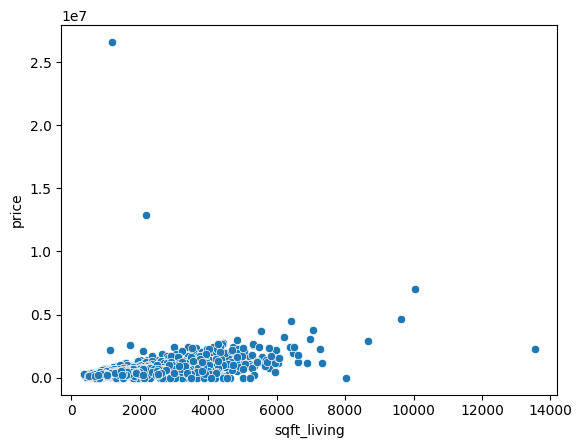

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='sqft_living', y='price', data=df)
plt.show()

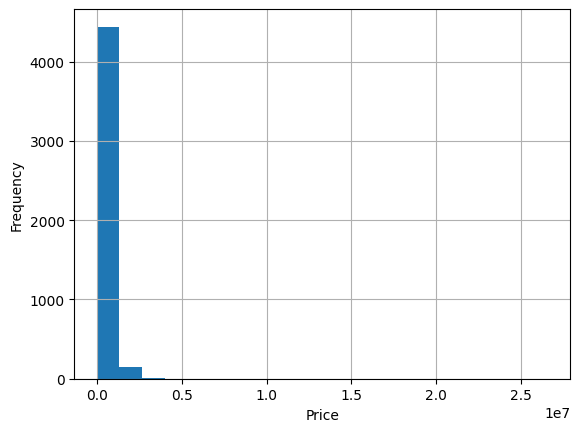

In [13]:
df['price'].hist(bins=20)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

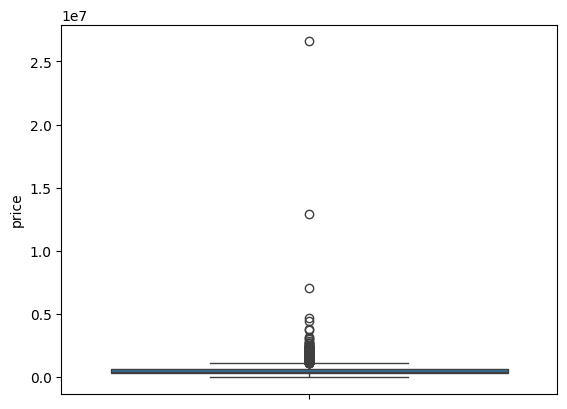

In [14]:
sns.boxplot(y=df['price'])
plt.show()

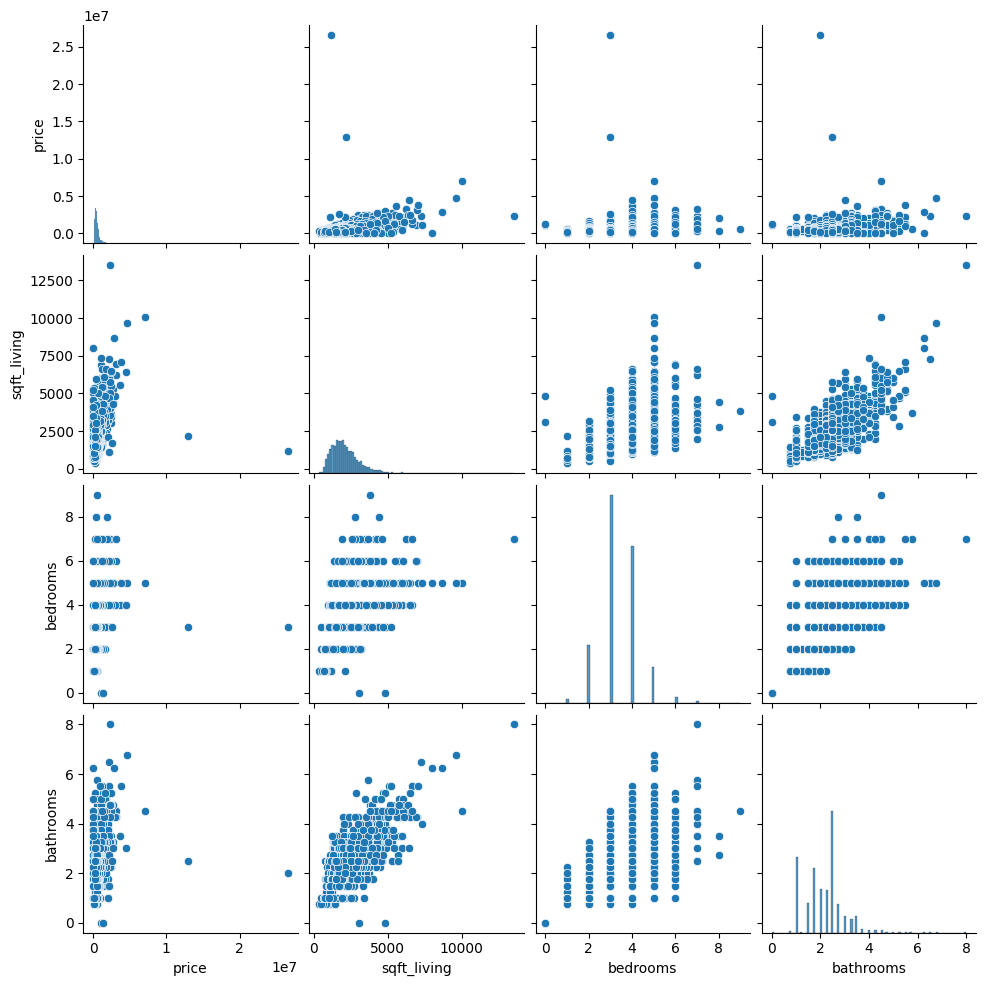

In [15]:
sns.pairplot(df[['price','sqft_living','bedrooms','bathrooms']])
plt.show()

In [16]:
df.isnull().sum()


,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ['date', 'street', 'city', 'statezip', 'country']:
    df[col] = encoder.fit_transform(df[col])

In [18]:
X = df.drop('price', axis=1)
y = df['price']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", root_mean_squared_error(y_test, y_pred_lr))

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf))

print("\nGradient Boosting")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_gb))

Linear Regression
MAE: 207816.8294166553
RMSE: 993048.575350367

Random Forest
MAE: 166803.2758949517
RMSE: 988204.1750187094

Gradient Boosting
MAE: 170872.99415203792
RMSE: 984757.6259828946


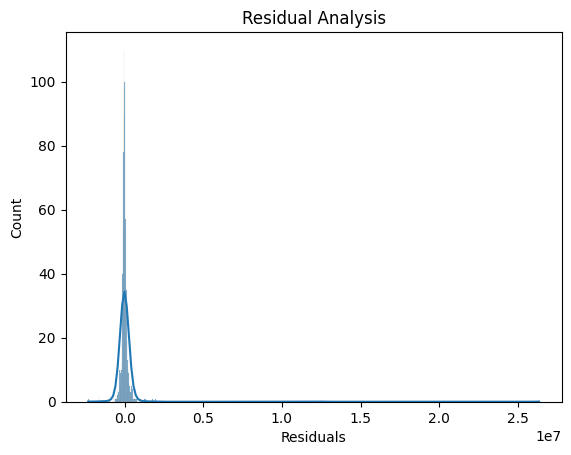

In [25]:
residuals = y_test - y_pred_rf

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Residual Analysis")
plt.show()

In [26]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

['house_price_model.pkl']

In [27]:
model = joblib.load("house_price_model.pkl")

sample = [X_test[0]]

prediction = model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 419892.72


In [28]:
print("Linear Regression RMSE:", root_mean_squared_error(y_test, y_pred_lr))
print("Random Forest RMSE:", root_mean_squared_error(y_test, y_pred_rf))
print("Gradient Boosting RMSE:", root_mean_squared_error(y_test, y_pred_gb))

Linear Regression RMSE: 993048.575350367
Random Forest RMSE: 988204.1750187094
Gradient Boosting RMSE: 984757.6259828946
